# Семестровое задание по дисциплине «Численные методы»

## Метод Монте-Карло, вариант 10

В работе выполняются три пункта:

1. Вычисление тройного интеграла методом Монте-Карло.
2. Решение системы линейных уравнений методом Монте-Карло.
3. Определение площади фигуры методом Монте-Карло и построение фигуры.

## Импорт библиотек и общие настройки

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
N = 100_000  # по заданию требуется N >= 10000
print(f'N = {N}')

N = 100000


## 1. Вычисление интеграла методом Монте-Карло

Для варианта 10 задан интеграл:

$$
I = \int_{0}^{1}\int_{1}^{2}\int_{0}^{3} (xy + yz)\,dx\,dy\,dz.
$$

То есть:

- $0 \le x \le 3$;
- $1 \le y \le 2$;
- $0 \le z \le 1$.

Формула метода Монте-Карло для тройного интеграла по прямоугольному параллелепипеду:

$$
I \approx V \cdot \frac{1}{N}\sum_{i=1}^{N} f(x_i, y_i, z_i),
$$

где $V = (b_x-a_x)(b_y-a_y)(b_z-a_z)$ — объём области интегрирования.

In [ ]:
rng_integral = np.random.default_rng(SEED)

# Границы интегрирования: dx dy dz
x_min, x_max = 0, 3
y_min, y_max = 1, 2
z_min, z_max = 0, 1

def f_integral(x, y, z):
    return x*y + y*z

x = rng_integral.uniform(x_min, x_max, N)
y = rng_integral.uniform(y_min, y_max, N)
z = rng_integral.uniform(z_min, z_max, N)

volume = (x_max - x_min) * (y_max - y_min) * (z_max - z_min)
I_mc = volume * f_integral(x, y, z).mean()

# Точное значение: E[y(x+z)] * V = 1.5 * (1.5 + 0.5) * 3 = 9
I_exact = 9.0
abs_error = abs(I_mc - I_exact)
rel_error = abs_error / abs(I_exact) * 100

print('Метод Монте-Карло:', I_mc)
print('Точное значение:', I_exact)
print('Абсолютная погрешность:', abs_error)
print('Относительная погрешность, %:', rel_error)

Метод Монте-Карло: 9.011546950354656
Точное значение: 9.0
Абсолютная погрешность: 0.01154695035465636
Относительная погрешность, %: 0.12829944838507065


## 2. Решение системы линейных уравнений методом Монте-Карло

Для варианта 10 из таблицы:

$$
\begin{cases}
x_1 = 0.7x_1 + 0.2x_2 + 0.4,\\
x_2 = 0.2x_1 + 0.8x_2 + 0.3.
\end{cases}
$$

Запишем систему в виде:

$$
x = Ax + \beta
$$

Тогда решение можно представить рядом Неймана:

$$
x = \beta + A\beta + A^2\beta + A^3\beta + \ldots
$$

Метод Монте-Карло оценивает компоненты этого ряда с помощью случайных траекторий марковской цепи.

In [ ]:
A = np.array([
    [0.7, 0.2],
    [0.2, 0.8]
], dtype=float)

beta = np.array([0.4, 0.3], dtype=float)

exact_solution = np.linalg.solve(np.eye(2) - A, beta)

print('Матрица A:')
print(A)
print('Вектор beta:')
print(beta)
print('Точное решение:')
print(exact_solution)

Матрица A:
[[0.7 0.2]
 [0.2 0.8]]
Вектор beta:
[0.4 0.3]
Точное решение:
[7.  8.5]


In [ ]:
def monte_carlo_linear_system(A, beta, trajectories=200_000, max_steps=500, seed=42):
    """Оценка решения x = A*x + beta методом Монте-Карло.

    Для каждой компоненты x_i моделируются случайные траектории,
    начинающиеся из состояния i. Матрица A положительная, поэтому
    вероятности переходов берутся пропорционально строкам A.
    """
    rng = np.random.default_rng(seed)
    n = len(beta)
    row_sums = A.sum(axis=1)
    P = A / row_sums[:, None]
    estimates = []

    for start in range(n):
        states = np.full(trajectories, start, dtype=np.int8)
        weights = np.ones(trajectories)
        sums = beta[states].astype(float).copy()

        for _ in range(max_steps):
            u = rng.random(trajectories)
            next_states = (u >= P[states, 0]).astype(np.int8)

            # A[state, next_state] / P[state, next_state] = сумма строки A[state]
            weights *= row_sums[states]
            states = next_states
            sums += weights * beta[states]

        estimates.append(sums.mean())

    return np.array(estimates)

mc_solution = monte_carlo_linear_system(A, beta, trajectories=200_000, max_steps=500, seed=SEED)

abs_errors = np.abs(mc_solution - exact_solution)
rel_errors = abs_errors / np.abs(exact_solution) * 100

print('Решение методом Монте-Карло:')
print(mc_solution)
print('Точное решение:')
print(exact_solution)
print('Абсолютные погрешности:')
print(abs_errors)
print('Относительные погрешности, %:')
print(rel_errors)

Решение методом Монте-Карло:
[7.00308066 8.5002854 ]
Точное решение:
[7.  8.5]
Абсолютные погрешности:
[0.00308066 0.0002854 ]
Относительные погрешности, %:
[0.0440094  0.00335766]


## 3. Определение площади фигуры методом Монте-Карло

Для варианта 10 фигура задаётся системой ограничений:

$$
\begin{cases}
-x^3 - y^3 < 2,\
-x + y < 2,\
-2 < x < 2,\
-2 < y < 2.
\end{cases}
$$

Ограничивающий прямоугольник:

$$
-2 < x < 2, \quad -2 < y < 2.
$$

Площадь прямоугольника:

$$
S_{прям} = 4 \cdot 4 = 16.
$$

Формула метода Монте-Карло для площади:

$$
S \approx S_{прям} \cdot \frac{K}{N},
$$

где $K$ — количество случайных точек, попавших внутрь фигуры.

In [ ]:
def inside_figure(x, y):
    return (
        (-x**3 - y**3 < 2) &
        (-x + y < 2) &
        (-2 < x) & (x < 2) &
        (-2 < y) & (y < 2)
    )

rng_area = np.random.default_rng(SEED + 1)

x_rect_min, x_rect_max = -2, 2
y_rect_min, y_rect_max = -2, 2
S_rect = (x_rect_max - x_rect_min) * (y_rect_max - y_rect_min)

x_points = rng_area.uniform(x_rect_min, x_rect_max, N)
y_points = rng_area.uniform(y_rect_min, y_rect_max, N)

inside = inside_figure(x_points, y_points)
K = inside.sum()
S_mc = S_rect * K / N

print('Площадь ограничивающего прямоугольника:', S_rect)
print('Количество точек N:', N)
print('Количество точек внутри K:', K)
print('Площадь фигуры методом Монте-Карло:', S_mc)

Площадь ограничивающего прямоугольника: 16
Количество точек N: 100000
Количество точек внутри K: 63718
Площадь фигуры методом Монте-Карло: 10.19488


In [ ]:
# Контрольное значение площади через численное интегрирование по x.
# Это не сам метод Монте-Карло, а проверка результата.

def y_length_for_x(x):
    # Из -x^3 - y^3 < 2 получаем y > cubic_root(-x^3 - 2)
    lower = max(-2.0, float(np.cbrt(-x**3 - 2)))

    # Из -x + y < 2 получаем y < x + 2
    upper = min(2.0, x + 2.0)

    return max(0.0, upper - lower)

try:
    from scipy.integrate import quad
    S_control, integration_error = quad(y_length_for_x, -2, 2, epsabs=1e-12)
except Exception:
    xs = np.linspace(-2, 2, 1_000_001)
    lengths = np.array([y_length_for_x(float(x)) for x in xs])
    S_control = np.trapezoid(lengths, xs)
    integration_error = np.nan

abs_area_error = abs(S_mc - S_control)
rel_area_error = abs_area_error / S_control * 100

print('Контрольное значение площади:', S_control)
print('Площадь методом Монте-Карло:', S_mc)
print('Абсолютная погрешность:', abs_area_error)
print('Относительная погрешность, %:', rel_area_error)

Контрольное значение площади: 10.202310910152939
Площадь методом Монте-Карло: 10.19488
Абсолютная погрешность: 0.007430910152939063
Относительная погрешность, %: 0.0728355587119396


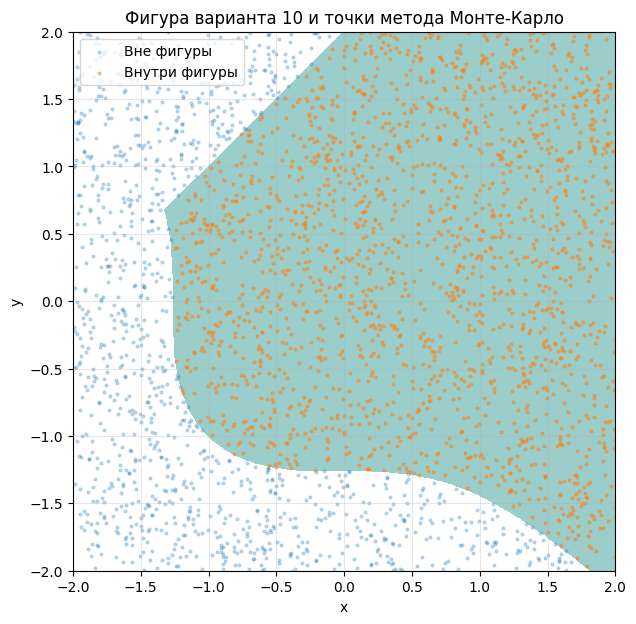

In [ ]:
# Построение фигуры и случайных точек
grid_n = 700
xs = np.linspace(-2, 2, grid_n)
ys = np.linspace(-2, 2, grid_n)
X, Y = np.meshgrid(xs, ys)
mask = inside_figure(X, Y)

plt.figure(figsize=(7, 7))
plt.contourf(X, Y, mask.astype(int), levels=[0.5, 1.5], alpha=0.45)

# Для читаемости на график выводим не все 100000 точек, а случайную часть
show_n = 3000
idx = np.random.default_rng(SEED).choice(N, size=show_n, replace=False)
inside_show = inside[idx]
plt.scatter(x_points[idx][~inside_show], y_points[idx][~inside_show], s=4, alpha=0.25, label='Вне фигуры')
plt.scatter(x_points[idx][inside_show], y_points[idx][inside_show], s=4, alpha=0.45, label='Внутри фигуры')

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Фигура варианта 10 и точки метода Монте-Карло')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Итоговые выводы

1. Метод Монте-Карло дал значение тройного интеграла, близкое к точному значению. При увеличении количества точек погрешность обычно уменьшается.
2. Система линейных уравнений была приведена к виду $x = Ax + \beta$ и решена методом Монте-Карло через случайные траектории. Полученное решение близко к точному решению, найденному через `numpy.linalg.solve`.
3. Площадь фигуры была найдена как доля случайных точек, попавших внутрь области, умноженная на площадь ограничивающего прямоугольника. Фигура построена на графике.